# Supporting 4 - Verification-gated screening on an independent reservoir

*Optional detail; start with `notebooks/00_START_HERE.ipynb`.*

The surrogate proposes; the simulator decides. `screening.Recommendation` refuses to hold a schedule that has not been simulated and found within both stated limits. Limits are modelling assumptions.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'demo'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')
from subsurfaceml.predict import Predictor
from subsurfaceml import screening as SC
from subsurfaceml.features import features_for_schedules
from subsurfaceml.final_eval import eval_realisations
from subsurfaceml.optimise import sample_candidates
P = Predictor(cfg)   # verified artifacts; raises with a rebuild command if missing
c, reals = eval_realisations(cfg, 'final_test')
r = reals[0]
print(r)

Realisation(realisation_id=10000, seed=20262204, k_median_mD=104.87222080491242, V_DP=0.7395982728252154, phi_mean=0.13586075725342503, h_total_m=32.697784758204655, r_e_m=2153.904547424148, n_g=2.7479672560006994, n_a=3.734266390388569, krg0=0.4224659296636868, S_ar=0.3497930525702666, mu_g_cP=0.0423910334137364, rho_g=687.5961576841597)


In [2]:
def predictor(R):
    X = features_for_schedules(c, r, R)
    _, p, hi = P.bands['dp_bh_max_MPa'].predict_interval(X)
    _, p2, hi2 = P.bands['r_plume_m95_m'].predict_interval(X)
    return {'dp': p, 'dp_hi': hi, 'r95': p2, 'r95_hi': hi2}
X0 = features_for_schedules(c, r, np.ones((1, c.schedule.n_periods)))
in_dom = bool(P.domain.check(X0)['in_domain'].iloc[0])
cands = sample_candidates(c, r, 2000, np.random.default_rng(0))
rec = SC.recommend_surrogate(c, r, SC.make_simulator(c, r), 4, predictor, cands, in_domain=in_dom)
print('status:', rec.status, '| flags:', rec.flags)
display(pd.DataFrame([ch.as_dict() for ch in rec.checks])[['label', 'rates_kg_s', 'dp_MPa', 'r95_m', 'mass_Mt', 'feasible']])
provenance('computed', f'{rec.n_simulations} simulations run in this session')

status: VERIFIED_FEASIBLE | flags: ['surrogate_out_of_domain', 'simulator_fallback']


,label,rates_kg_s,dp_MPa,r95_m,mass_Mt,feasible
0,constant_0,"[2.0663301530562284, 2.0663301530562284, 2.0663301530562284, 2.0663301530562...",8.991721,311.529231,0.326042,True


[COMPUTED NOW in this notebook session]  1 simulations run in this session


## What happens when nothing can be verified

A limit no candidate can meet must give an explicit outcome and no recommendation.

In [3]:
import copy
c2 = copy.deepcopy(c); c2.optim.p_limit_MPa = c2.solver.p_init_MPa + 0.05   # 0.05 MPa build-up
rec2 = SC.recommend_surrogate(c2, r, SC.make_simulator(c2, r), 2, predictor, cands, fallback=None)
print('status:', rec2.status, '| recommended:', rec2.recommended_rates_kg_s, '|', rec2.notes)

status: NO_CANDIDATE_PREDICTED_FEASIBLE | recommended: None | no candidate predicted within the limits


## All screened reservoirs of the pipeline run

,realisation_id,set,method,status,mass_Mt,mass_vs_constant_pct,n_simulations,flags
0,10000,final_test,simulator_constant,VERIFIED_FEASIBLE,0.320,0.000,4,NaN
1,10000,final_test,rom_constant,VERIFIED_FEASIBLE,0.326,1.956,1,NaN
2,10000,final_test,surrogate_published,VERIFIED_FEASIBLE,0.283,-11.457,3,NaN
3,10000,final_test,rom_shaped,VERIFIED_FEASIBLE,0.342,7.009,1,NaN
4,10000,final_test,surrogate_verified,VERIFIED_FEASIBLE,0.326,1.956,1,surrogate_out_of_domain;simulator_fallback
5,10001,final_test,simulator_constant,VERIFIED_FEASIBLE,1.073,0.000,4,NaN
6,10001,final_test,rom_constant,VERIFIED_FEASIBLE,1.083,0.865,1,NaN
7,10001,final_test,surrogate_published,VERIFIED_FEASIBLE,0.951,-11.409,3,NaN
8,10001,final_test,rom_shaped,VERIFIED_FEASIBLE,1.114,3.769,1,NaN
9,10001,final_test,surrogate_verified,VERIFIED_FEASIBLE,1.099,2.377,4,scaled_up_by_simulator


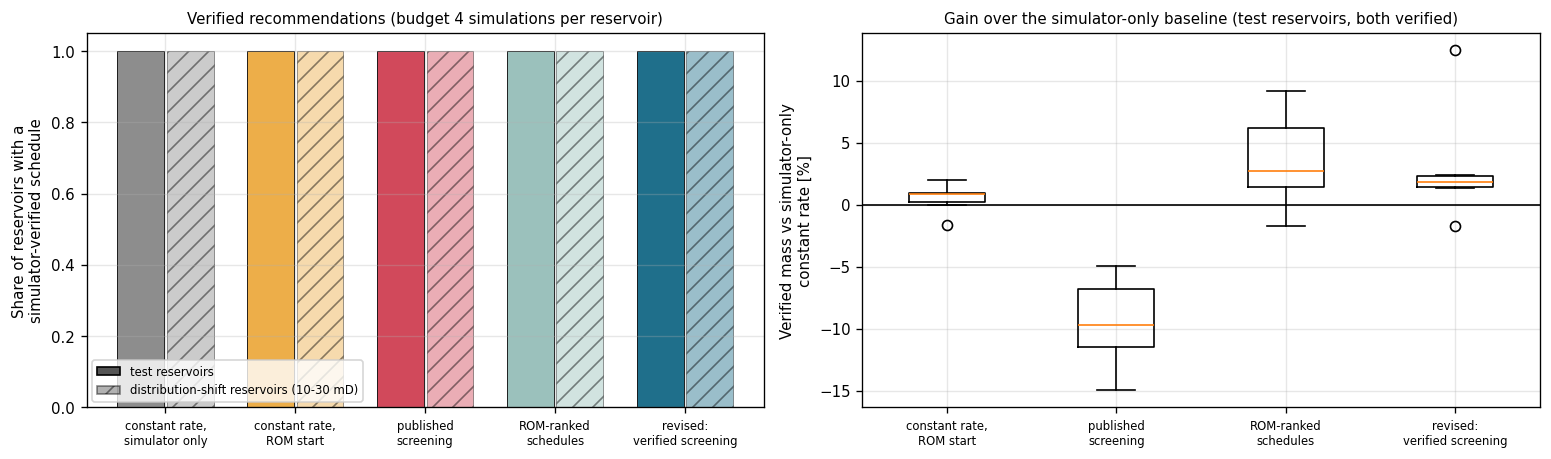

[LOADED from the completed demo run]  screening results of the completed demo run


In [4]:
rec_all = pd.read_csv(Path(cfg.paths.metrics)/'screening_recommendations.csv')
display(rec_all[['realisation_id', 'set', 'method', 'status', 'mass_Mt', 'mass_vs_constant_pct',
                 'n_simulations', 'flags']].round(3))
display(Image(str(Path(cfg.paths.figures)/'15_schedule_screening.png')))
provenance('loaded', 'screening results of the completed demo run')